In [11]:
import sys
from pathlib import Path
sys.path.append(str(Path('../../../src').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler


from utils.variants import VARIANT_DEFS, apply_variant

# --- Paths ---
MODELS_DIR = Path("../../../data/out/best_models_lstm/validation_lstm/models")
PLOTS_CUSTOM = Path("../../../data/out/best_models_lstm/validation_lstm/plots_custom")
PLOTS_CUSTOM.mkdir(parents=True, exist_ok=True)



In [12]:
# ----------------------------------------------------------------------
# Dataset de validación externo
df_val = pd.read_csv("../../../data/out/dataset_validation_final.csv")
df_val["FECHA_HORA"] = pd.to_datetime(df_val["FECHA_HORA"], dayfirst=True, errors="coerce")
y_val = df_val["PRECIO"].astype("float32")

# Crear eje temporal manual
fechas = pd.date_range(start="2025-07-01 00:00", periods=len(y_val), freq="H")


def prepare_variant_data_for_lstm(df, scaler=None, fit=False, target_column='PRECIO',
                                  timesteps=24,
                                  categorical_numeric=["YEAR","MONTH","DAY","HORA","NIVEL_ENSO","DIA_SEMANA","FESTIVO"]):
    """
    Prepara secuencias para LSTM a partir de un DataFrame ya transformado por la variante.
    - Si fit=True, ajusta el scaler con los datos numéricos.
    - Si fit=False, solo transforma con el scaler ya entrenado.
    Devuelve X_seq, y_seq completos (sin split).
    """
    df = df.drop(columns=['FECHA_HORA'], errors='ignore')

    # Separar numéricas y categóricas
    numeric_cols = [c for c in df.columns if c not in categorical_numeric + [target_column]]
    X_num = df[numeric_cols].values.astype('float32') if numeric_cols else None
    X_cat = df[[c for c in categorical_numeric if c in df.columns]].values.astype('float32')
    y = df[target_column].values.astype('float32')

    # Escalar solo numéricas
    if X_num is not None:
        if fit:
            scaler.fit(X_num)
        X_num_scaled = scaler.transform(X_num)
        X_all = np.concatenate([X_num_scaled, X_cat], axis=1)
    else:
        X_all = X_cat

    # Construir secuencias
    X_seq, y_seq = [], []
    for i in range(len(X_all) - timesteps):
        X_seq.append(X_all[i:i+timesteps, :])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

# ----------------------------------------------------------------------
# Función para predecir con un modelo ya entrenado
def predict_with_lstm_variant(variant, config_name, df_val, timesteps=24):
    # 1. Reconstruir dataset de validación según la variante
    vdef = next(v for v in VARIANT_DEFS if v["name"] == variant)
    df_val_var, _ = apply_variant(df_val.copy(), vdef, date_col="FECHA_HORA")

    # 2. Preparar secuencias de validación (ajustando scaler sobre df_val)
    scaler = MinMaxScaler()
    X_val_seq, y_val_seq = prepare_variant_data_for_lstm(
        df_val_var, scaler=scaler, fit=True, timesteps=timesteps
    )

    # 3. Cargar modelo entrenado
    model_file = MODELS_DIR / f"{variant}_{config_name}.h5"
    model = load_model(model_file)

    # 4. Predecir
    y_pred = model.predict(X_val_seq, verbose=0).ravel()

    # 5. Alinear fechas
    fechas_seq = fechas[timesteps:]

    return y_val_seq, y_pred, fechas_seq

C:\Users\Camilo\AppData\Local\Temp\ipykernel_18548\3470804332.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas = pd.date_range(start="2025-07-01 00:00", periods=len(y_val), freq="H")


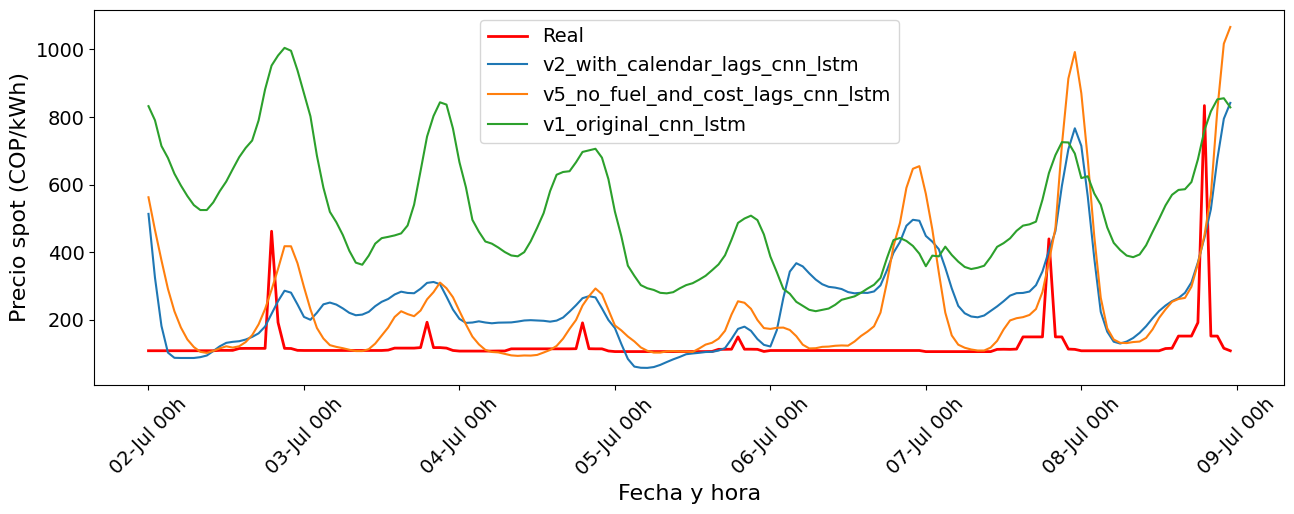

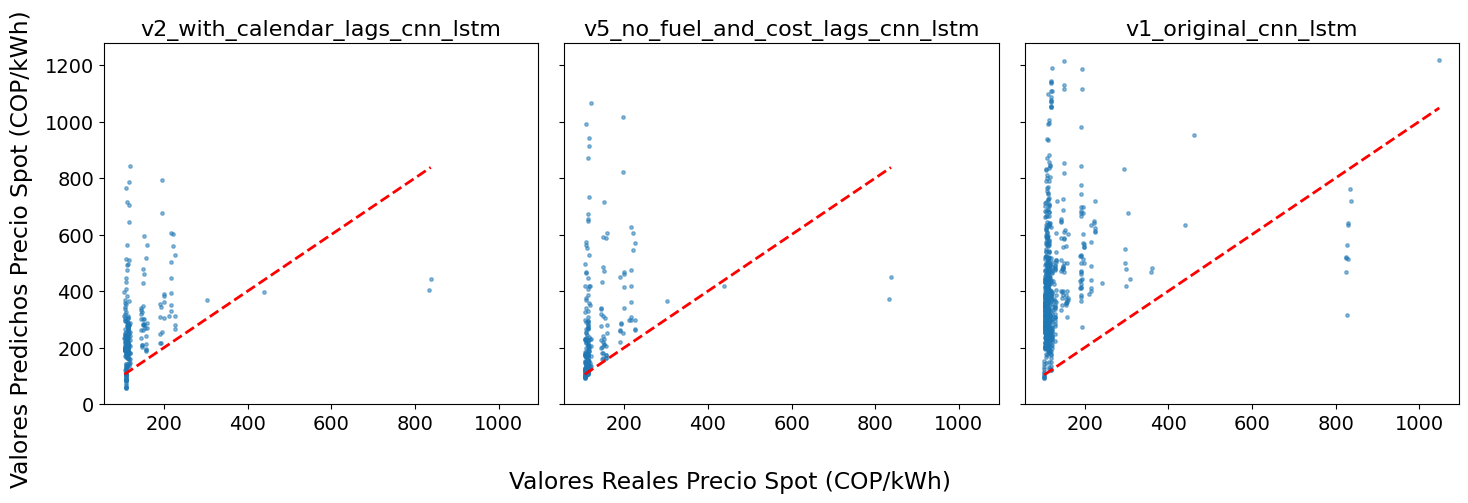

In [ ]:
# Ajustar tamaño de fuentes en matplotlib
plt.rcParams.update({
    "font.size": 14,          # tamaño base
    "axes.titlesize": 16,     # títulos de ejes
    "axes.labelsize": 16,     # etiquetas de ejes
    "xtick.labelsize": 14,    # ticks eje X
    "ytick.labelsize": 14,    # ticks eje Y
    "legend.fontsize": 14     # leyenda
})


# ----------------------------------------------------------------------
# Top 3 modelos seleccionados
top_models = [
    ("v2_with_calendar_lags", "cnn_lstm"),
    ("v5_no_fuel_and_cost_lags", "cnn_lstm"),
    ("v1_original", "cnn_lstm")
]

predicciones = {}
for variant, config_name in top_models:
    y_seq, y_pred, fechas_seq = predict_with_lstm_variant(variant, config_name, df_val, timesteps=24)
    predicciones[f"{variant}_{config_name}"] = (y_seq, y_pred, fechas_seq)

# ----------------------------------------------------------------------
# 1. Predicciones vs reales (Top 3 en una sola gráfica)
n_observations = 24 * 7  # 7 días

plt.figure(figsize=(14,5))
plt.plot(fechas_seq[:n_observations], y_seq[:n_observations],
         label="Real", color="red", linewidth=2)

for name, (y_seq, y_pred, fechas_seq) in predicciones.items():
    plt.plot(fechas_seq[:n_observations], y_pred[:n_observations], label=name)

plt.xlabel("Fecha y hora")
plt.ylabel("Precio spot (COP/kWh)")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)
plt.savefig(PLOTS_CUSTOM / "pred_top3_lstm.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

# ----------------------------------------------------------------------
# 2. Scatter (Top 3 en subplots)
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

for ax, (name, (y_seq, y_pred, _)) in zip(axes, predicciones.items()):
    lims = [y_seq.min(), y_seq.max()]
    ax.scatter(y_seq, y_pred, s=6, alpha=0.5)
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_title(name)

fig.supxlabel("Valores Reales Precio Spot (COP/kWh)")
fig.supylabel("Valores Predichos Precio Spot (COP/kWh)")
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "scatter_top3_lstm.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()
